## Ejercicios de parcial

En las notebooks anteriores se desarrollaron e implementaron **desde cero** distintos algoritmos para representar y manipular rotaciones en el espacio tridimensional. En particular, se trabajó con:

* **Ángulos de Euler**
* **Representación eje–ángulo**
* **Cuaterniones**
* Conversión **directa e inversa** entre estas representaciones y matrices de rotación

El objetivo de esos desarrollos fue **comprender los fundamentos matemáticos** de estas representaciones y analizar aspectos importantes como:

* singularidades,
* estabilidad numérica,
* equivalencia entre distintas parametrizaciones de la orientación.

Una vez establecido este marco conceptual, en esta notebook se utilizarán directamente las herramientas provistas por **Robotics Toolbox for Python**, en particular el módulo **SpatialMath for Python**.

Estas librerías implementan de forma robusta y eficiente las operaciones con transformaciones espaciales que se utilizan habitualmente en **robótica**, tales como:

* matrices de rotación (SO(3)),
* transformaciones homogéneas (SE(3)),
* conversiones entre distintas representaciones de orientación.

De esta manera, en los ejercicios que siguen **no será necesario reimplementar los algoritmos**, sino que se utilizarán directamente las funciones de la biblioteca. El foco pasará entonces a:

* interpretar los resultados,
* relacionar las distintas representaciones,
* y aplicar estas herramientas a problemas típicos de cinemática y representación espacial en robótica.


In [1]:
import roboticstoolbox as rtb
import spatialmath as sm
import numpy as np

## Ejercicio 1

Se tiene la terna 2 desplazada $p_{12}=[3,4,5]^\top$ y rotada según $e_1=[0,1,1]^\top$ un ángulo de 12 grados.

Luego la terna 3 está desplazada $p_{23}=[0,-2,-1]^\top$ y rotada según $e_2=[1,-1,0]^\top$ un ángulo de -20 grados.

Calcular el desplazamiento que debo hacer para ir desde el origen de la terna 1 al de la terna 3 en la dirección de $x_1$ (precisión 0.001)

In [5]:
# Armo la matriz homogénea de rototraslación que expresa la terna 2 en la 1
A_21 = sm.SE3.Trans([3,4,5]) @ sm.SE3.AngleAxis(12,[0,1,1],unit='deg')
print(A_21)

# Revisemos cuál es el eje de rotación mirando el autovector
w,v = np.linalg.eig(A_21.R)
print("Autovector:",np.round(v[:,-1],6))
print("Autovalor:",w[-1])

   0.9781   -0.147     0.147     3         
   0.147     0.9891    0.01093   4         
  -0.147     0.01093   0.9891    5         
   0         0         0         1         

Autovector: [0.      +0.j 0.707107+0.j 0.707107+0.j]
Autovalor: (1+0j)


In [12]:
# Obtengo la segunda rototraslación
A_32 = sm.SE3.Trans([0,-2,-1]) @ sm.SE3.AngleAxis(-20,[1,-1,0],unit='deg')
print(A_32)

# Calculo la relación entre la primera y la última
A_31 = A_21@A_32
print(A_31)

print("Distancia entre origen de terna 0 y terna 3, en la dirección x_1 =",np.round(A_31.t[0],4))


   0.9698   -0.03015   0.2418    0         
  -0.03015   0.9698    0.2418   -2         
  -0.2418   -0.2418    0.9397   -1         
   0         0         0         1         

   0.9175   -0.2076    0.3392    3.147     
   0.1101    0.9522    0.285     2.011     
  -0.3821   -0.2242    0.8965    3.989     
   0         0         0         1         

Distancia entre origen de terna 0 y terna 3, en la dirección x_1 = 3.147


# Ejercicio 2

Idem anterior, calculando el desplazamiento que debo hacer para ir desde el origen de la terna 1 al de la terna 3 en la dirección de $x_3$ (precisión 0.001)

In [13]:
# El ejercicio es idéntico al anterior, solo que pide la distancia del origen de la terna 1 a la 3 
# expresada en terna 3 (dice según x_3), y p_31 por convención viene en terna 1
# Entonces tengo que proyectar!!!
# Para esto uso la matriz de rotación

pp = np.transpose(A_31.R) @ A_31.t
print("Distancia entre origen de terna 0 y terna 3, en la dirección x_3 =",np.round(pp[0],4))

Distancia entre origen de terna 0 y terna 3, en la dirección x_3 = 1.5846


# Ejercicio 3

Sea 
$$R=\begin{bmatrix} 1 &0 &0\\0 &0 &1\\0&-1& 0\end{bmatrix}$$

Hallar los ángulos de Euler que describen la rotación.

In [22]:
R = sm.SO3([[1,0,0],
            [0,0,1],
            [0,-1,0]])
print(R)

# El método eul devuelve los ángulos de Euler ZYZ. Pero una sola de las soluciones
phi,theta,psi = R.eul()
print("Solución 1:", [phi,theta,psi])
print("Solución 2:", [phi+np.pi, -theta, psi+np.pi])

print("RPY ZYX :", R.rpy())
print("Axis-angle:", R.angvec())
print("Quaternion:", R.UnitQuaternion())

   1         0         0         
   0         0         1         
   0        -1         0         

Solución 1: [1.5707963267948966, 1.5707963267948966, -1.5707963267948966]
Solución 2: [4.71238898038469, -1.5707963267948966, 1.5707963267948966]
RPY ZYX : [-1.57079633 -0.          0.        ]
Axis-angle: (1.5707963267948966, array([-1.,  0.,  0.]))
Quaternion:  0.7071 << -0.7071,  0.0000,  0.0000 >>


## Una nota sobre los ángulos Roll–Pitch–Yaw (RPY)

La representación **Roll–Pitch–Yaw (RPY)** es otra parametrización de la orientación basada en tres rotaciones elementales.

En muchos contextos de robótica (por ejemplo en **ROS 2**) los ángulos RPY se definen como una secuencia de rotaciones **extrínsecas Z–Y–X**, es decir:

$$
R = R_z(\psi), R_y(\theta), R_x(\phi)
$$

donde:

* $\psi$ : **yaw** (rotación alrededor de $Z_0$)
* $\theta$ : **pitch** (rotación alrededor de $Y_0$)
* $\phi$ : **roll** (rotación alrededor de $X_0$)

Sin embargo, una secuencia de rotaciones **extrínsecas Z–Y–X** es equivalente a una secuencia de rotaciones **intrínsecas X–Y–Z**.

Por lo tanto, puede interpretarse también como:

1. rotación **roll** alrededor del eje $X_0$
2. rotación **pitch** alrededor del eje $Y_1$
3. rotación **yaw** alrededor del eje $Z_2$

En consecuencia, cuando se expresa el triplete

$
(\phi,\theta,\psi)
$

* el **primer valor corresponde a la rotación alrededor del eje $X$**,
* el segundo a la rotación alrededor del eje $Y$,
* y el tercero a la rotación alrededor del eje $Z$.

Esta convención es la que implementa el método `rpy()` del módulo **SpatialMath for Python** utilizado en estas notebooks.

## Ejercicio 4

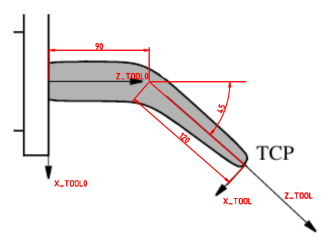

Se tiene una herramienta montada en la brida. 
Se tienen definidas las ternas tool0 y tool. Calcular el elemento $(2,2)$ de la matriz de rototraslación que expresa la tool en tool0 $A^{tool}_{tool0}$ con 2 decimales de precisión.

In [25]:
A_tool_tool0 = sm.SE3.Trans([120*np.cos(np.pi/4),0,90+120*np.sin(np.pi/4)])@ sm.SE3.AngleAxis(45,[0,1,0],unit='deg')

print(A_tool_tool0.R[1,1])



1.0


# Ejercicio 5

Se tiene una herramienta definida por la traslación
$$p = [100 ,50 ,25]$$
y la rotación expresada como cuaternión:
$$Q = [0.00221 ,0.999 ,0.00299 , -0.000259]$$

La definición consiste en expresar la roto-traslación que lleva desde la brida de montaje al punto principal de la herramienta (o TCP).
Luego de una modificación en el taller, se reemplaza la placa de montaje a la brida del robot por una que es 10mm de mayor espesor.

Expresar la nueva definición de la herraminta

In [35]:
# Armo el cuaternión
Q = sm.UnitQuaternion([0.00221, 0.999, 0.00299, -0.000259])
# Vector de traslación
p = np.array([100, 50, 25])

# Armo la transformación homogénea
A_tool = sm.SE3.Rt(Q.R, p)
print(A_tool)

# Me dice que la placa de montaje es 10mm más gruesa. Esto aporta distancia en la dirección z_tool0
A_brida = sm.SE3.Trans(0,0,10)
print(A_brida)

print("Nuevo montaje\n", A_brida@A_tool)

   1         0.005987 -0.0005053  100       
   0.005985 -1        -0.004426  50        
  -0.0005318  0.004423 -1         25        
   0         0         0         1         

   1         0         0         0         
   0         1         0         0         
   0         0         1         10        
   0         0         0         1         

Nuevo montaje
    1         0.005987 -0.0005053  100       
   0.005985 -1        -0.004426  50        
  -0.0005318  0.004423 -1         35        
   0         0         0         1         



# Ejercicio 6
Dada la matriz de rotación
$$ 
R=\begin{bmatrix} 0.834493 & -0.488523 & -0.254887\\
   0.494440 &  0.868049 & -0.044943\\
   0.243210 & -0.088521 &  0.965926
   \end{bmatrix}
$$

Hallar $\psi$ de los ángulos de Euler ZYZ expresado en grados para $\theta$ mayor a 0 (precisión 0.01)


In [58]:
Rmat=np.array([[ 0.834,  -0.489 , -0.255],
   [0.494,   0.868,  -0.045],
   [0.243,  -0.089,   0.966]])

# Descomentar para ver que no anda
#R = sm.SO3(Rmat)

print("Determinante de R=",np.linalg.det(Rmat))
print("R*R'=\n",Rmat @ Rmat.T)

# Con este redondeo queda evidente que la matriz no es de rotación
# Llevo la matriz R a la ortogonal más cercana

U,S,Vt = np.linalg.svd(Rmat)
print("Valores singulares S=\n",S)
Rmat_rec = U@Vt

print("Determinante de R recuperado=",np.linalg.det(Rmat_rec))
print("Rmat_rec*Rmat_rec'=\n",Rmat_rec @ Rmat_rec.T)


R = sm.SO3(Rmat_rec)
print("Angulos de Euler (solución positiva): ",R.eul())

Determinante de R= 0.9996557429999999
R*R'=
 [[ 9.997020e-01 -9.810000e-04 -1.470000e-04]
 [-9.810000e-04  9.994850e-01 -6.800000e-04]
 [-1.470000e-04 -6.800000e-04  1.000126e+00]]
Valores singulares S=
 [1.0004046  1.00005719 0.9991943 ]
Determinante de R recuperado= 0.9999999999999997
Rmat_rec*Rmat_rec'=
 [[ 1.00000000e+00  2.40326563e-16  8.37757612e-17]
 [ 2.40326563e-16  1.00000000e+00 -1.96692607e-16]
 [ 8.37757612e-17 -1.96692607e-16  1.00000000e+00]]
Angulos de Euler (solución positiva):  [-2.96764263  0.26187904 -2.79175564]


# Ejercicio 7

Calcular el componente $x$ del vector
$$r=[10,5,15]^\top$$
luego de ser rotado a través de un eje dado por el vector 
$$ e=[1,-1,4]^\top $$
un ángulo de 15 grados (precisión 0.01) y trasladado por un vector 
$$p=[5,-15,2]^\top$$

Ayuda: podemos pensar al vector $r$ solidario a una terna 1 que se ha trasladado en p y rotado según e respecto de una terna 0. Con esto armamos A que pasa de la 1 a la 0. Luego calculamos el vector resultado multiplicando ya que el resultado debiera quedar en la terna 0


In [70]:
A = sm.SE3.Rt(sm.SO3.AngleAxis(15,[1,-1,4],unit='deg'),[5,-15,2])
print(A)

r = np.array([10,5,15])
r2 = A * r
print(r2[0])


   0.9678   -0.2459   -0.05343   5         
   0.2421    0.9678   -0.06858  -15        
   0.06858   0.05343   0.9962    2         
   0         0         0         1         

[12.6471557]
